<a href="https://colab.research.google.com/github/pooriaazami/how_to_deeply_code_2026/blob/main/DeepLearningCodeing_S2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader

import torchvision as tv
import torchvision.transforms as T

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score

from tqdm.notebook import tqdm

In [45]:
BATCH_SIZE = 8
EPOCHS = 10
LR = 1e-4

In [2]:
transform = T.ToTensor()

train_dataset = tv.datasets.MNIST(
    root='.', download=True, train=True, transform=transform
)

val_dataset = tv.datasets.MNIST(
    root='.', download=True, train=False, transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 76.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 41.3MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 22.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.65MB/s]


In [5]:
train_dataloader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
)

val_dataloader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=True,
)

In [13]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR)

In [47]:
preds_log = []
labels_log = []
loss_log = []
accuracy_log = []

for epoch in range(1, EPOCHS+1):
  print(f'Epoch {epoch} / {EPOCHS}')
  total_loss = 0
  for x, y in tqdm(train_dataloader):
    optimizer.zero_grad()

    preds = model(x)
    loss = loss_fn(preds, y)

    loss.backward()
    optimizer.step()

    total_loss += loss.detach().cpu().item()
    preds_log.extend(preds.argmax(1).cpu().tolist())
    labels_log.extend(y.cpu().tolist())

  accuracy = accuracy_score(labels_log, preds_log)
  loss_log.append(total_loss)
  accuracy_log.append(accuracy)

  print(f'Loss: {total_loss:.2}, Accuracy: {accuracy:.2f}')

Epoch 1 / 10


  0%|          | 0/7500 [00:00<?, ?it/s]

Loss: 6.4e+02, Accuracy: 0.97
Epoch 2 / 10


  0%|          | 0/7500 [00:00<?, ?it/s]

Loss: 5.5e+02, Accuracy: 0.98
Epoch 3 / 10


...

Loss: 2.6e+02, Accuracy: 0.98
Epoch 9 / 10


  0%|          | 0/7500 [00:00<?, ?it/s]

Loss: 2.3e+02, Accuracy: 0.98
Epoch 10 / 10


  0%|          | 0/7500 [00:00<?, ?it/s]

Loss: 2.1e+02, Accuracy: 0.99


In [ ]:
with torch.no_grad():
  for x, y in val_dataloader:
    preds =  model(x)

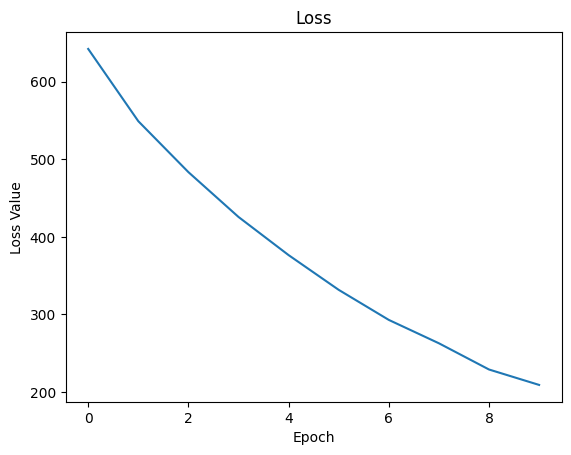

In [49]:
plt.plot(loss_log)
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.show()

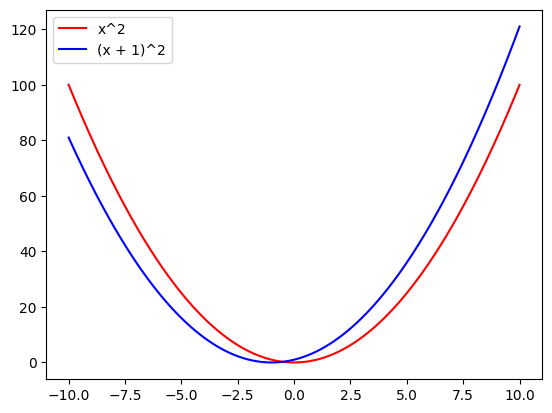

In [58]:
x = np.linspace(-10, 10, 500)

plt.plot(x, x**2, color='red', label='x^2') # x ^ 2, (x + 1) ^ 2
plt.plot(x, (x + 1) ** 2, color='blue', label='(x + 1)^2')

plt.legend()

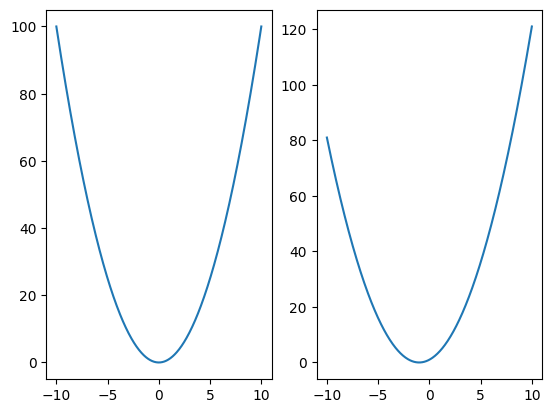

In [60]:
fig, axs = plt.subplots(1, 2)

axs[0].plot(x, x**2)
axs[1].plot(x, (x+1)**2)

In [40]:
l = []

l

[]

In [43]:
l.extend([1, 2, 3, 4])

In [44]:
l

[1, 2, 3, 4, 1, 2, 3, 4]